In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [55]:
#Load Image Dataset
from sklearn.datasets import fetch_openml
import numpy as np

fashion = fetch_openml('Fashion-MNIST', version=1)

X = fashion.data.values       #Flattened images (784 features)
y = fashion.target.astype(int)  #Labels (0–9)

#Reshape to image format
images = X.reshape(-1, 28, 28)

print('Data shape:', X.shape)
print('Image shape:', images[0].shape)

Data shape: (70000, 784)
Image shape: (28, 28)


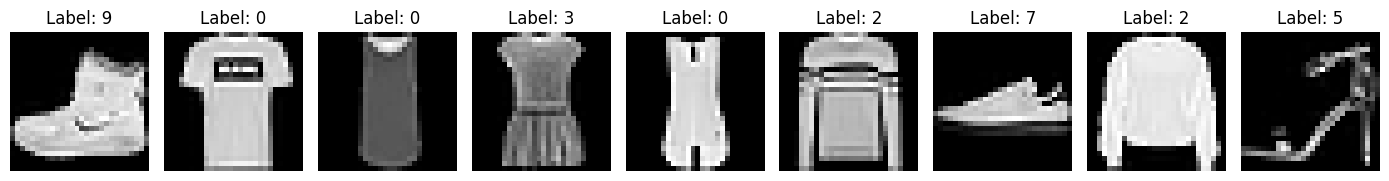

In [56]:
# Visualize Sample Images
plt.figure(figsize=(14,3))   # increase width

for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [58]:
#Full SVD Decomposition
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

print('U shape:', U.shape)
print('Σ length:', S.shape)
print('Vᵀ shape:', VT.shape)

U shape: (70000, 784)
Σ length: (784,)
Vᵀ shape: (784, 784)


In [73]:
#Dimensionality Reduction (k = 50)
k = 50
U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]

X_reduced = U_k @ S_k
print('Reduced data shape:', X_reduced.shape)

Reduced data shape: (70000, 50)


Explained variance of first 10 components:
[0.22092292 0.14402605 0.05463431 0.05089914 0.04055179 0.03015082
 0.02751402 0.02316674 0.01697467 0.01321401]
Cumulative explained variance of first 10 components:
[0.22092292 0.36494897 0.41958328 0.47048242 0.51103421 0.54118504
 0.56869905 0.59186579 0.60884046 0.62205447]
Total variance captured by k components: 0.8010697690788376


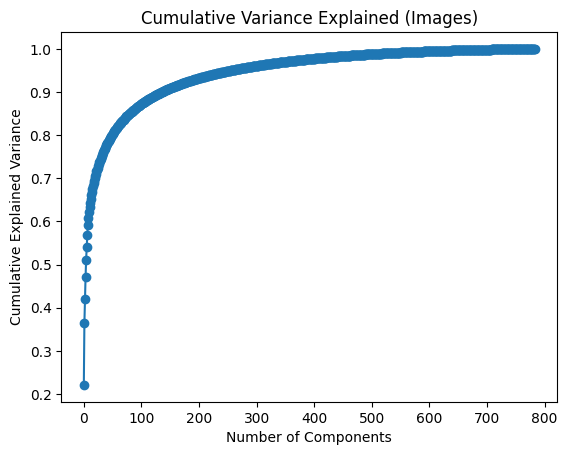

In [74]:
#Explained Variance by Singular Values
explained_variance = (S**2) / np.sum(S**2)

# Print variance values
print("Explained variance of first 10 components:")
print(explained_variance[:10])

print("Cumulative explained variance of first 10 components:")
print(np.cumsum(explained_variance[:10]))

print("Total variance captured by k components:", np.sum(explained_variance[:k]))

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained (Images)')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


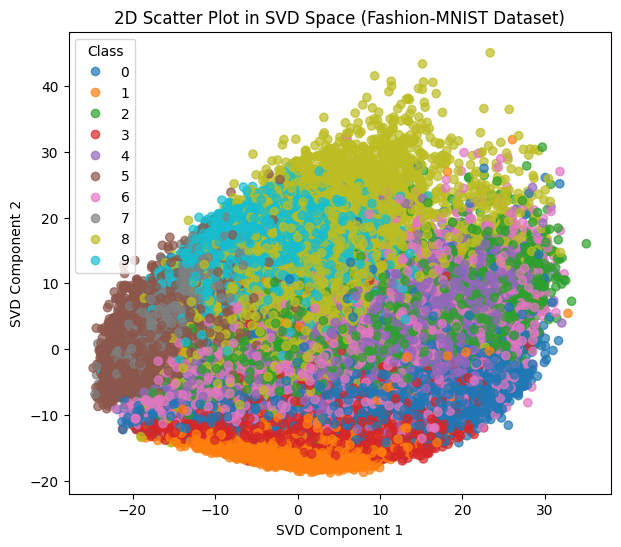

In [61]:
#2D Scatter plot using first two SVD components
k_scatter = 2
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_2D = U_k_scatter @ S_k_scatter

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("2D Scatter Plot in SVD Space (Fashion-MNIST Dataset)")
plt.legend(*scatter.legend_elements(), title="Class")
plt.show()

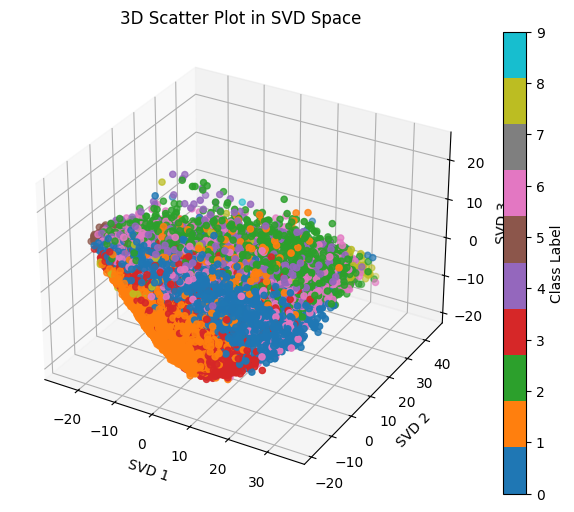

In [62]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D

k_scatter = 3
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_3D = U_k_scatter @ S_k_scatter

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_3D[:,0], X_3D[:,1], X_3D[:,2], c=y, cmap='tab10')

ax.set_xlabel("SVD 1")
ax.set_ylabel("SVD 2")
ax.set_zlabel("SVD 3")
ax.set_title("3D Scatter Plot in SVD Space")
fig.colorbar(p, label="Class Label")
plt.show()

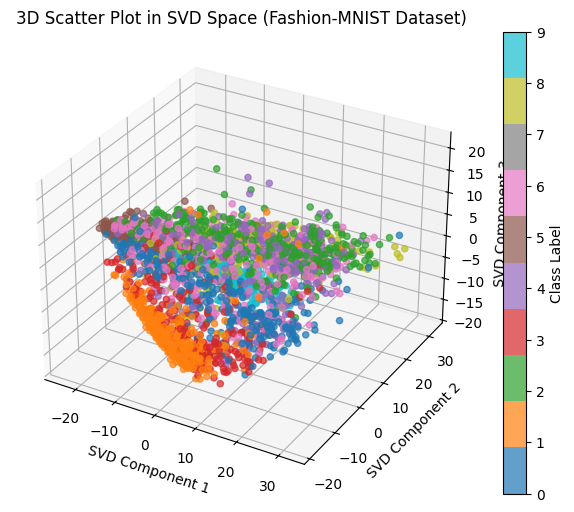

In [63]:
#3D Scatter Plot
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

k_scatter = 3
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_3D = U_k_scatter @ S_k_scatter

#Randomly sample 3000 points for better visualization
idx = np.random.choice(len(X_3D), 3000, replace=False)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(X_3D[idx,0], X_3D[idx,1], X_3D[idx,2],
               c=y[idx], cmap='tab10', alpha=0.7)

ax.set_xlabel("SVD Component 1")
ax.set_ylabel("SVD Component 2")
ax.set_zlabel("SVD Component 3")
ax.set_title("3D Scatter Plot in SVD Space (Fashion-MNIST Dataset)")

fig.colorbar(p, label="Class Label")

plt.show()

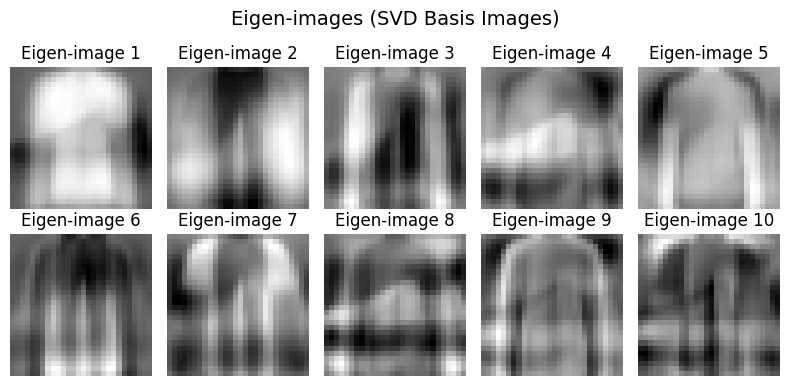

In [64]:
# Visualizing Eigen-images (basis images)
num_eigenimages = 10  #show first 10 basis images

plt.figure(figsize=(8,4))

for i in range(num_eigenimages):
    plt.subplot(2, 5, i+1)

    eigenimage = VT[i].reshape(28, 28)
    plt.imshow(eigenimage, cmap='gray')

    plt.title(f"Eigen-image {i+1}")
    plt.axis('off')

plt.suptitle("Eigen-images (SVD Basis Images)", fontsize=14)
plt.tight_layout()
plt.show()

Original image shape: (28, 28)


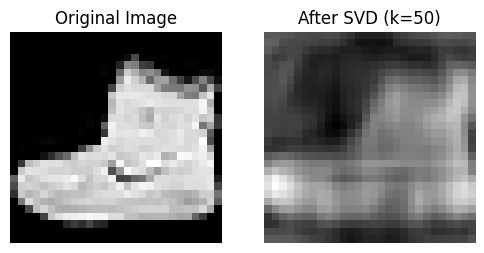

In [65]:
#Select an image index
image_index = 0

#Original image
original_image = images[image_index]

print("Original image shape:", original_image.shape)

index = image_index

#Reconstruct image using reduced SVD components
reconstructed = (U_k[index] @ S_k @ VT_k).reshape(28, 28)

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title('After SVD (k=50)')
plt.axis('off')

plt.show()

In [66]:
#Multiclass Classification WITHOUT SVD

#Convert labels to integers (important for Fashion-MNIST)
y = y.astype(int)
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_no_svd = LogisticRegression(max_iter=5000, multi_class='ovr')
clf_no_svd.fit(X_train, y_train)
y_pred_no_svd = clf_no_svd.predict(X_test)
acc_no_svd = accuracy_score(y_test, y_pred_no_svd)
acc_no_svd

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.8475238095238096

In [67]:
#Multiclass Classification WITH SVD
svd = TruncatedSVD(n_components=50, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)

clf_svd = LogisticRegression(max_iter=5000, multi_class='ovr')
clf_svd.fit(X_train_svd, y_train)
y_pred_svd = clf_svd.predict(X_test_svd)
acc_svd = accuracy_score(y_test, y_pred_svd)
acc_svd

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.8213809523809524

In [76]:
from sklearn.metrics import classification_report
print("Classification Report WITHOUT SVD")
print(classification_report(y_test, y_pred_no_svd))

print("Classification Report WITH SVD")
print(classification_report(y_test, y_pred_svd))

Classification Report WITHOUT SVD
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      2076
           1       0.97      0.96      0.96      2108
           2       0.76      0.76      0.76      2094
           3       0.84      0.87      0.86      2148
           4       0.74      0.78      0.76      2070
           5       0.93      0.93      0.93      2144
           6       0.66      0.55      0.60      2131
           7       0.91      0.93      0.92      2076
           8       0.93      0.94      0.94      2017
           9       0.95      0.94      0.95      2136

    accuracy                           0.85     21000
   macro avg       0.85      0.85      0.85     21000
weighted avg       0.85      0.85      0.85     21000

Classification Report WITH SVD
              precision    recall  f1-score   support

           0       0.75      0.82      0.78      2076
           1       0.97      0.95      0.96      2108
           2 

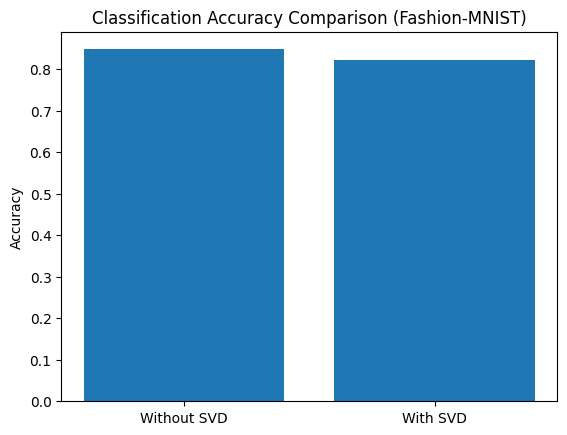

In [68]:
#Accuracy Comparison
plt.figure()
plt.bar(['Without SVD', 'With SVD'], [acc_no_svd, acc_svd])
plt.ylabel('Accuracy')
plt.title('Classification Accuracy Comparison (Fashion-MNIST)')
plt.show()

In [69]:
#Confusion Matrix (With SVD)
print(confusion_matrix(y_test, y_pred_svd))

[[1694    6   38  149    5    5  133    1   42    3]
 [   8 2003   11   60    7    1   15    0    3    0]
 [  40    6 1477   18  328    1  204    0   20    0]
 [ 100   29   24 1821   78    1   86    0    9    0]
 [   5    6  186   77 1575    2  192    2   24    1]
 [   3    1    5    2    0 1947    4  127   18   37]
 [ 397    4  304  114  250    8 1002    1   50    1]
 [   0    0    0    0    0  116    0 1844    7  109]
 [  16    2    8   24    5   16   31    4 1907    4]
 [   1    0    0    0    0   47    2  107    0 1979]]


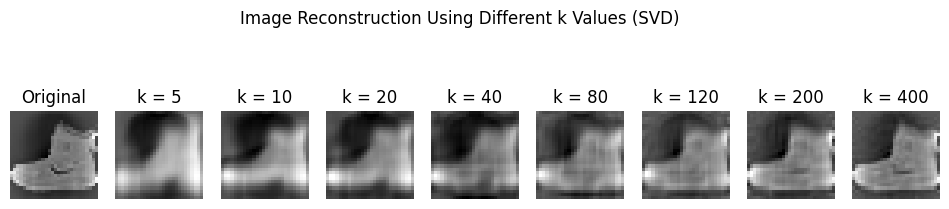

In [71]:
#Image reconstruction for different k values
image_index = 0  #choose any image
original = X_scaled[image_index].reshape(28,28)

k_values = [5, 10, 20, 40, 80, 120, 200, 400]

plt.figure(figsize=(12,3))

#Original image
plt.subplot(1, len(k_values)+1, 1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

#Reconstructions
for i, k in enumerate(k_values):
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]

    reconstructed = (U_k[image_index] @ S_k @ VT_k).reshape(28,28)

    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.suptitle("Image Reconstruction Using Different k Values (SVD)")
plt.show()